# 03 — The Partition Function and Base-Pair Probabilities

## Learning objectives

By the end of this notebook you will be able to:

- Explain why a **single MFE structure** can be a misleading summary of how an
  RNA actually behaves, and what the **Boltzmann ensemble** of structures is.
- Compute the **partition function** $Z$ and **ensemble free energy** with
  `fold_compound.pf()`, and relate it to the per-structure free energies from
  notebook 2.
- Compute and visualize the **base-pair probability matrix** ("dot plot") with
  `fold_compound.bpp()`, including alternative/competing pairings that a single
  structure cannot show.
- Use **positional entropy** to quantify how well-defined (or ambiguous) the
  structure is at each position.
- Compare the **MFE**, **centroid**, and **maximum expected accuracy (MEA)**
  structures and explain when they differ.

**Prerequisites**: [01_introduction.ipynb](01_introduction.ipynb) and
[02_mfe_folding.ipynb](02_mfe_folding.ipynb) — dot-bracket notation, MFE,
`eval_structure`, and the nearest-neighbor free-energy sum.


## 1. Introduction & motivation

Notebook 2 treated $\Delta G(s\mid x)$ as a property of *one* structure $s$ —
the MFE structure. But at thermal equilibrium, an RNA molecule does not sit
frozen in its single lowest-energy shape: it **fluctuates** through many
structures, visiting each with a probability set by its free energy. The MFE
structure is just the *most probable single structure* — for many sequences it
still has only a small share of the total probability, with many close
competitors.

This matters in practice: a riboswitch or thermometer RNA *works* precisely
because two (or more) structures are both substantially populated, and the
balance between them shifts with ligand binding or temperature. A tool that
only reports "the" MFE structure would hide this entirely.

**Roadmap**: theory first (the partition function, base-pair probabilities,
and the related MEA/centroid/positional-entropy quantities), then three
worked examples — a "well-behaved" sequence with one dominant structure, a
sequence with **two genuinely competing structures**, and a small case study
ranking several sequences by how well-defined their ensembles are.


## 2. Theoretical background

### 2.1 The Boltzmann ensemble and the partition function

At equilibrium, the probability of secondary structure $s$ for sequence $x$ is

$$
p(s \mid x) \;=\; \frac{\exp\!\big(-\Delta G(s\mid x) / RT\big)}{Z(x)},
\qquad
Z(x) \;=\; \sum_{s \,\in\, \Omega(x)} \exp\!\big(-\Delta G(s\mid x)/RT\big),
$$

where $\Omega(x)$ is the set of *all* secondary structures compatible with
$x$, $R$ is the gas constant, and $T$ is the absolute temperature. $Z(x)$ — the
**partition function** — sums the Boltzmann factors of every structure, not
just the best one. McCaskill's algorithm computes $Z(x)$ (and the quantities
below) in the same $O(n^3)$ time as MFE folding, by replacing each
"minimize energy" step of the MFE recursions with "sum Boltzmann factors".

The **ensemble free energy**

$$
\Delta G_{\text{ens}}(x) \;=\; -RT \ln Z(x)
$$

is always $\leq \Delta G(s^*\mid x)$ for the MFE structure $s^*$ — adding more
(positive-probability) terms to the sum inside $Z$ can only lower $-RT\ln Z$.
The gap $\Delta G(s^*) - \Delta G_{\text{ens}}$ measures how much additional
stability comes from the "cloud" of suboptimal structures around the MFE.

### 2.2 Base-pair probabilities

The **base-pair probability** $p_{ij}$ is the total probability mass of all
structures that contain the pair $(i,j)$:

$$
p_{ij} \;=\; \sum_{s \,\in\, \Omega(x):\, (i,j) \in s} p(s\mid x).
$$

McCaskill's algorithm computes the entire matrix $\{p_{ij}\}$ without
enumerating structures. Plotting $p_{ij}$ for all $i<j$ as a heatmap — the
classic **RNA "dot plot"** — reveals not just the MFE pairs but *every*
pairing that is appreciably populated, including alternatives the MFE
structure does not use.

### 2.3 Positional entropy

For each position $i$, the **positional entropy**

$$
S_i \;=\; -\sum_j p_{ij}\log_2 p_{ij} \;-\; p_{i,\text{unpaired}}\log_2 p_{i,\text{unpaired}}
$$

(computed by `positional_entropy()`) summarizes how many different pairing
states position $i$ visits with appreciable probability. $S_i \approx 0$ means
position $i$ is essentially always paired (or unpaired) the same way — a
"well-defined" position; $S_i$ large means $i$ is genuinely ambiguous.

### 2.4 Representative structures beyond the MFE

Two other single structures are often reported alongside the MFE:

- **Centroid**: the structure in $\Omega(x)$ with minimum total base-pair
  distance to all other structures, weighted by probability — in practice,
  built from pairs with $p_{ij} > 0.5$. `fold_compound.centroid()`.
- **MEA (maximum expected accuracy)**: the structure maximizing
  $\sum_{(i,j)\in s} 2\gamma\, p_{ij} + \sum_{i \text{ unpaired in } s} p_{i,\text{unpaired}}$
  for a parameter $\gamma$ (default 1) — a principled trade-off between
  including likely pairs and avoiding unlikely ones. `fold_compound.MEA()`.

### 2.5 Theory-to-API map

| Theory concept | ViennaRNA API |
| :--- | :--- |
| Partition function $Z(x)$, ensemble free energy $\Delta G_{\text{ens}}$ | `fold_compound.pf()` → `(structure, ensemble_energy)` |
| Base-pair probability matrix $\{p_{ij}\}$ | `fold_compound.bpp()` (call **after** `pf()`) |
| Positional entropy $S_i$ | `fold_compound.positional_entropy()` |
| Centroid structure | `fold_compound.centroid()` |
| MEA structure | `fold_compound.MEA()` |
| Ensemble defect (expected base-pair distance of $s$ to the ensemble) | `fold_compound.ensemble_defect(s)` |


In [1]:
# --- Setup -------------------------------------------------------------
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import RNA

with contextlib.redirect_stderr(io.StringIO()):
    import forgi.graph.bulge_graph as fgb
    import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PALETTE = sns.color_palette("deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})


def dotbracket_to_pairs(structure):
    '''Return a set of 0-indexed (i, j) base-pair tuples, i < j.'''
    stack, pairs = [], set()
    for pos, ch in enumerate(structure):
        if ch == "(":
            stack.append(pos)
        elif ch == ")":
            pairs.add((stack.pop(), pos))
    return pairs


def plot_dot_plot(sequence, fc, mfe_structure, ax, title=None):
    '''RNA 'dot plot': upper triangle = base-pair probabilities,
    lower triangle = MFE pairs (binary), shared diagonal of zeros.'''
    n = len(sequence)
    bpp = np.array(fc.bpp())[1:, 1:]  # drop the unused 0-index row/col
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            matrix[i, j] = bpp[i, j]
    for (i, j) in dotbracket_to_pairs(mfe_structure):
        matrix[j, i] = 1.0

    sns.heatmap(matrix, ax=ax, cmap="rocket_r", vmin=0, vmax=1,
                 cbar_kws={"label": "probability  /  MFE pair"}, square=True)
    ax.set_xlabel("Sequence position $j$")
    ax.set_ylabel("Sequence position $i$")
    ax.set_title(title or "Dot plot: ensemble probabilities (upper) vs. MFE (lower)")
    return ax


## 3. Worked example 1 — a sequence with one dominant structure

We start with the hairpin-within-hairpin sequence from notebooks 1–2. Its MFE
structure was a clear winner there; here we check whether the *ensemble*
agrees, by comparing the ensemble free energy to the MFE and looking at the
dot plot and positional entropy profile.


In [2]:
seq_1 = "GGGAAACCCAAAGGGAAACCC"

fc_1 = RNA.fold_compound(seq_1)
mfe_structure_1, mfe_1 = fc_1.mfe()
fc_1.exp_params_rescale(mfe_1)   # numerically stable Boltzmann factors near the MFE
_, ensemble_energy_1 = fc_1.pf()
centroid_1, centroid_dist_1 = fc_1.centroid()
mea_1, mea_score_1 = fc_1.MEA()

print(f"Sequence:           {seq_1}")
print(f"MFE structure:      {mfe_structure_1}  ({mfe_1:.2f} kcal/mol)")
print(f"Centroid structure: {centroid_1}  (mean bp distance {centroid_dist_1:.2f})")
print(f"MEA structure:      {mea_1}  (MEA score {mea_score_1:.2f})")
print(f"Ensemble free energy: {ensemble_energy_1:.2f} kcal/mol")
print(f"MFE - ensemble gap:   {mfe_1 - ensemble_energy_1:.2f} kcal/mol  (suboptimal-structure 'cloud')")


Sequence:           GGGAAACCCAAAGGGAAACCC
MFE structure:      (((...(((...)))...)))  (-5.80 kcal/mol)
Centroid structure: (((...(((...)))...)))  (mean bp distance 1.97)
MEA structure:      (((...(((...)))...)))  (MEA score 18.82)
Ensemble free energy: -5.97 kcal/mol
MFE - ensemble gap:   0.17 kcal/mol  (suboptimal-structure 'cloud')


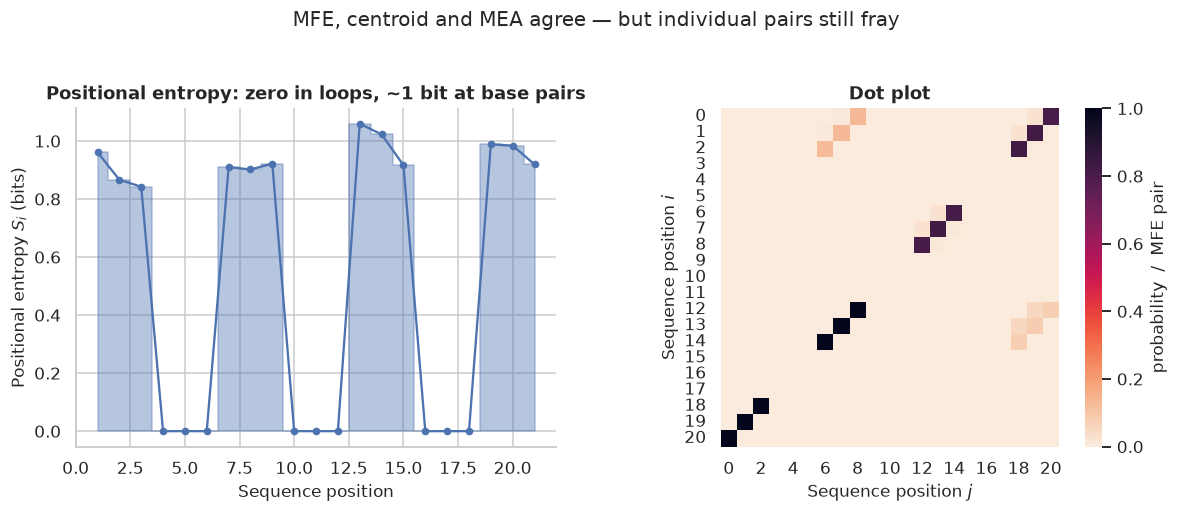

In [3]:
fig = plt.figure(figsize=(11, 4.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1])

ax0 = fig.add_subplot(gs[0])
positions = np.arange(1, len(seq_1) + 1)
entropy_1 = fc_1.positional_entropy()[1:]  # drop index 0
ax0.fill_between(positions, entropy_1, color=PALETTE[0], alpha=0.4, step="mid")
ax0.plot(positions, entropy_1, color=PALETTE[0], marker="o", ms=4, lw=1.5)
ax0.set_xlabel("Sequence position")
ax0.set_ylabel(r"Positional entropy $S_i$ (bits)")
ax0.set_title("Positional entropy: zero in loops, ~1 bit at base pairs")
sns.despine(ax=ax0)

ax1 = fig.add_subplot(gs[1])
plot_dot_plot(seq_1, fc_1, mfe_structure_1, ax1, title="Dot plot")

fig.suptitle("MFE, centroid and MEA agree — but individual pairs still fray", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: positional entropy is exactly zero at the loop
positions (5–6 and 17–18, confidently unpaired in every populated structure)
but is around **1 bit at every paired position** — *not* zero. The dot plot
explains why: the upper-triangle probabilities at the MFE pair positions are
noticeably lighter ($p_{ij}\approx 0.4$–$0.6$) than the solid lower-triangle
MFE markers (which are always drawn at 1.0). An entropy of 1 bit is exactly
what you get from a two-state position that is paired about half the time and
unpaired the rest — i.e. the helices **fray**: each individual base pair has
real probability of being open, even though the *pattern* of pairing (which
partner, if any) is unambiguous. This is why the MFE, centroid, and MEA
structures above are all identical — there is only one *candidate* structure
with appreciable weight — while the MFE–ensemble gap (0.17 kcal/mol) and
positional entropy are both modest but nonzero.


## 4. Worked example 2 — a sequence with two competing structures

Now consider a sequence built from two near-identical "C...G" hairpin motifs
separated by a spacer, designed so the 5$'$ C-rich tract can pair with
**either** G-rich tract downstream. Both pairings are plausible, so we expect
the ensemble to split its probability between two structures — exactly the
situation a single MFE structure cannot represent.


In [4]:
seq_2 = "CCCCAAAAGGGGAAAACCCCAAAAGGGG"

fc_2 = RNA.fold_compound(seq_2)
mfe_structure_2, mfe_2 = fc_2.mfe()
fc_2.exp_params_rescale(mfe_2)
_, ensemble_energy_2 = fc_2.pf()
centroid_2, centroid_dist_2 = fc_2.centroid()
mea_2, mea_score_2 = fc_2.MEA()

print(f"Sequence:           {seq_2}")
print(f"MFE structure:      {mfe_structure_2}  ({mfe_2:.2f} kcal/mol)")
print(f"Centroid structure: {centroid_2}  (mean bp distance {centroid_dist_2:.2f})")
print(f"MEA structure:      {mea_2}  (MEA score {mea_score_2:.2f})")
print(f"Ensemble free energy: {ensemble_energy_2:.2f} kcal/mol")
print(f"MFE - ensemble gap:   {mfe_2 - ensemble_energy_2:.2f} kcal/mol")

# Report the strongest base pairs not present in the MFE structure.
bpp_2 = np.array(fc_2.bpp())[1:, 1:]
mfe_pairs_2 = dotbracket_to_pairs(mfe_structure_2)
alt = [(i, j, bpp_2[i, j]) for i in range(len(seq_2)) for j in range(i + 1, len(seq_2))
       if bpp_2[i, j] > 0.1 and (i, j) not in mfe_pairs_2]
alt_df = pd.DataFrame(alt, columns=["i", "j", "probability"]).sort_values("probability", ascending=False)
alt_df


Sequence:           CCCCAAAAGGGGAAAACCCCAAAAGGGG
MFE structure:      ((((....))))....((((....))))  (-13.20 kcal/mol)
Centroid structure: ((((....))))....((((....))))  (mean bp distance 6.99)
MEA structure:      ((((....))))....((((....))))  (MEA score 20.93)
Ensemble free energy: -13.59 kcal/mol
MFE - ensemble gap:   0.39 kcal/mol


,i,j,probability
2,2,25,0.423495
1,1,26,0.423365
5,9,18,0.423294
6,10,17,0.423243
3,3,24,0.422097
4,8,19,0.421897
7,11,16,0.418023
0,0,27,0.401722


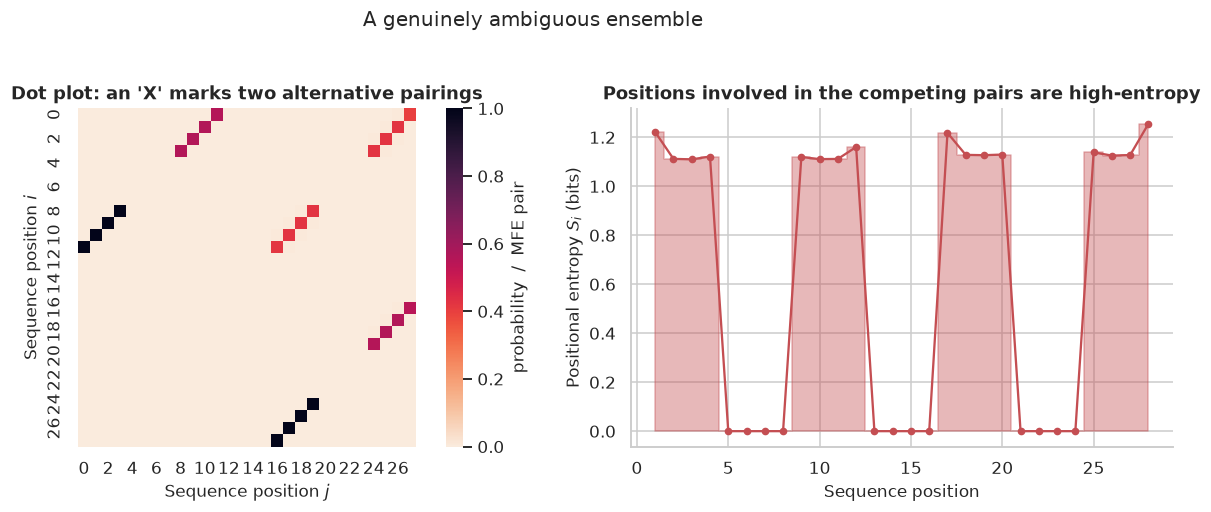

In [5]:
fig = plt.figure(figsize=(12, 4.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1])

ax0 = fig.add_subplot(gs[0])
plot_dot_plot(seq_2, fc_2, mfe_structure_2, ax0,
               title="Dot plot: an 'X' marks two alternative pairings")

ax1 = fig.add_subplot(gs[1])
positions = np.arange(1, len(seq_2) + 1)
entropy_2 = fc_2.positional_entropy()[1:]
ax1.fill_between(positions, entropy_2, color=PALETTE[3], alpha=0.4, step="mid")
ax1.plot(positions, entropy_2, color=PALETTE[3], marker="o", ms=4, lw=1.5)
ax1.set_xlabel("Sequence position")
ax1.set_ylabel(r"Positional entropy $S_i$ (bits)")
ax1.set_title("Positions involved in the competing pairs are high-entropy")
sns.despine(ax=ax1)

fig.suptitle("A genuinely ambiguous ensemble", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: the dot plot's upper triangle shows **two**
families of off-diagonal squares with comparable intensity — one connecting
the first C-tract to the *nearer* G-tract (the MFE pairing, $p\approx0.56$),
and one connecting it to the *farther* G-tract ($p\approx0.42$, the table
above). Every position involved in either pairing has positional entropy
around 1 bit — "I am paired about half the time, to one of two different
partners" — while the spacer positions (entropy $\approx 0$) are confidently
unpaired in both alternatives. The MFE structure alone (a single dot-bracket
string) cannot communicate this two-way split; the dot plot and entropy
profile can.


### 4.1 Comparing MFE, centroid, and MEA side by side

MFE, centroid, and MEA are computed by three different criteria, so in general
they need not agree. For this sequence they happen to coincide — the
**ambiguity** is about which partner the C-tract pairs with, and all three
criteria pick the same (more probable) partner. Drawing all three with `forgi`
makes that agreement visible directly; for a sequence where the criteria
*disagree*, the same three-panel layout would show visibly different
structures.


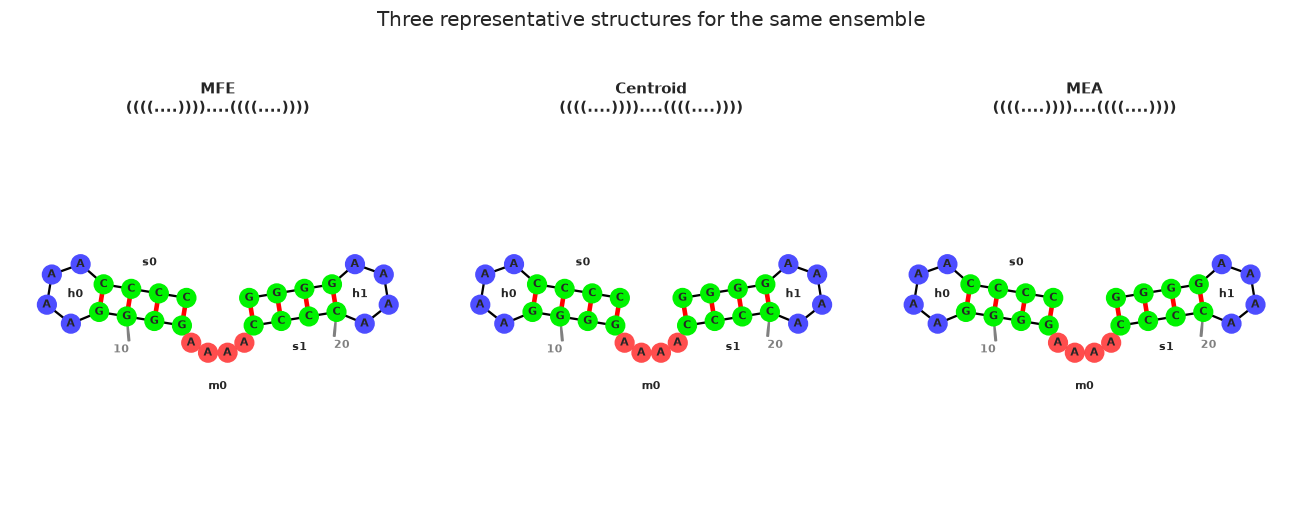

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
for ax, (label, structure) in zip(axes, [
    ("MFE", mfe_structure_2),
    ("Centroid", centroid_2),
    ("MEA", mea_2),
]):
    bg = fgb.BulgeGraph.from_dotbracket(structure, seq_2)
    fvm.plot_rna(bg, ax=ax, text_kwargs={"fontsize": 7}, lighten=0.3)
    ax.set_title(f"{label}\n{structure}", fontsize=10)
    ax.set_axis_off()

fig.suptitle("Three representative structures for the same ensemble", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


## 5. Case study — ranking sequences by ensemble "sharpness"

The **MFE–ensemble free-energy gap** and the **mean positional entropy** both
quantify, in different ways, how sharply peaked a sequence's ensemble is
around its MFE structure. We compute both for a small panel of sequences —
the fraying hairpin, the competing-structure sequence, and a poly-A sequence
that cannot form any base pairs at all — and rank them.


In [7]:
sequences = {
    "Fraying hairpin": seq_1,
    "Competing structures": seq_2,
    "Poly-A (no pairs possible)": "A" * 30,
}

rows = []
for name, seq in sequences.items():
    fc = RNA.fold_compound(seq)
    structure, mfe = fc.mfe()
    fc.exp_params_rescale(mfe)
    _, ensemble_energy = fc.pf()
    mean_entropy = float(np.mean(fc.positional_entropy()[1:]))
    rows.append({
        "sequence": name,
        "mfe": mfe,
        "ensemble_energy": ensemble_energy,
        "gap": mfe - ensemble_energy,
        "mean_entropy": mean_entropy,
    })

ranking_df = pd.DataFrame(rows).sort_values("mean_entropy")
ranking_df


,sequence,mfe,ensemble_energy,gap,mean_entropy
2,Poly-A (no pairs possible),0.0,-0.000000,0.000000,0.000000
0,Fraying hairpin,-5.8,-5.967788,0.167788,0.537748
1,Competing structures,-13.2,-13.587200,0.387200,0.654050


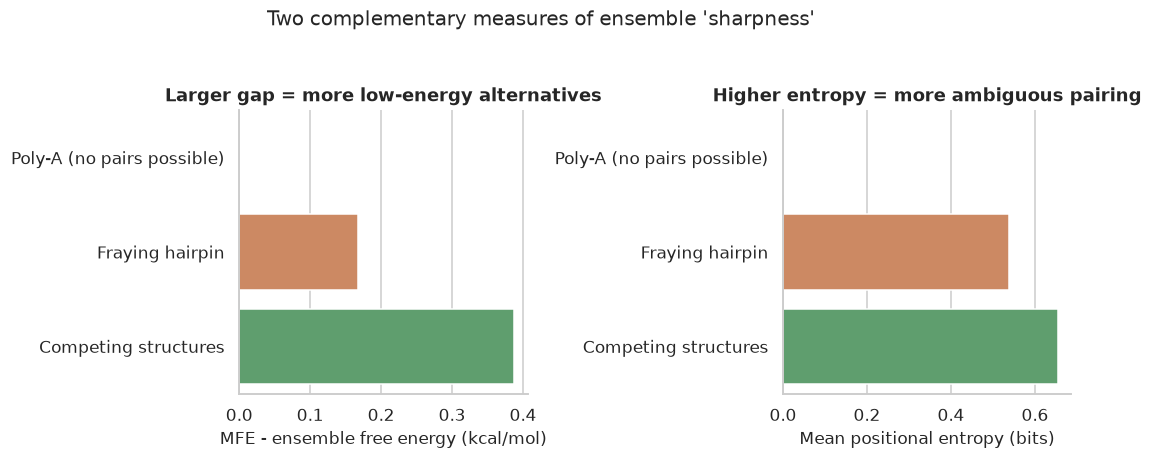

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=ranking_df, y="sequence", x="gap", hue="sequence",
            palette=PALETTE[:len(ranking_df)], legend=False, ax=axes[0])
axes[0].set_xlabel("MFE - ensemble free energy (kcal/mol)")
axes[0].set_ylabel("")
axes[0].set_title("Larger gap = more low-energy alternatives")

sns.barplot(data=ranking_df, y="sequence", x="mean_entropy", hue="sequence",
            palette=PALETTE[:len(ranking_df)], legend=False, ax=axes[1])
axes[1].set_xlabel("Mean positional entropy (bits)")
axes[1].set_ylabel("")
axes[1].set_title("Higher entropy = more ambiguous pairing")

for ax in axes:
    sns.despine(ax=ax)

fig.suptitle("Two complementary measures of ensemble 'sharpness'", y=1.04, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: poly-A sits at **zero** on both measures — with
no possible base pairs, $Z$ has exactly one term (the unfolded chain), so
$\Delta G_{\text{ens}} = \Delta G(\text{unfolded}) = \text{MFE} = 0$ and every
$p_{ij}=0$, giving zero entropy everywhere. This is the trivial end of the
scale: "confidently unstructured" is *also* a sharp ensemble. The fraying
hairpin and the competing-structure sequence both have nonzero gap and
entropy, but for different reasons (Sections 3–4): the former from
individual-pair fraying, the latter from a genuine fork between two
structures — and the competing-structure sequence scores higher on **both**
measures, since it combines fraying *and* a two-way ambiguity. The two
measures agree on the overall ranking here, but only positional entropy
tells you *where* the ambiguity is located (Section 4).


## 6. Best practices and common pitfalls

- **Call `pf()` before `bpp()`, `centroid()`, `MEA()`, or
  `positional_entropy()`** — these all read from the partition-function
  matrices that `pf()` fills in. Calling them first raises an error or returns
  stale data.
- **Call `exp_params_rescale(mfe)` before `pf()`** for sequences that are long
  or have very negative MFEs. Without it, the Boltzmann factors
  $\exp(-\Delta G/RT)$ can overflow; rescaling shifts the energy origin to the
  MFE so factors stay numerically well-behaved without changing any
  probability.
- **`bpp()` is 1-indexed and upper-triangular** — `bpp()[0]` is an unused
  placeholder row, and only entries with $i<j$ are filled. Slicing `[1:, 1:]`
  (as in `plot_dot_plot` above) gives a clean 0-indexed, sequence-length
  matrix.
- **The MFE–ensemble gap is always $\geq 0$** by construction (Section 2.1);
  if you compute a negative gap, check that `exp_params_rescale` was called
  with *that* sequence's MFE, not a stale value from a previous sequence.
- **MFE = centroid = MEA is the common case for short, well-designed
  sequences** — don't expect them to differ unless the sequence is genuinely
  ambiguous (Section 4) or quite long. Don't over-interpret small differences
  on toy examples.
- **Positional entropy is in bits**, not probability — a position with two
  equally likely pairing partners (and otherwise confidently paired/unpaired)
  has entropy 1, not 0.5.


## 7. Summary

- The **partition function** $Z$ sums Boltzmann factors over *all* structures;
  $\Delta G_{\text{ens}} = -RT\ln Z \leq \Delta G(s^*)$ always, with the gap
  measuring the weight of suboptimal structures.
- **Base-pair probabilities** $p_{ij}$, visualized as a **dot plot**, reveal
  alternative pairings that a single MFE structure hides — including genuinely
  competing structures.
- **Positional entropy** localizes ambiguity to specific sequence positions,
  complementing the global MFE–ensemble gap.
- **Centroid** and **MEA** structures offer alternatives to the MFE that are
  defined directly from the ensemble, and tend to agree with the MFE for
  unambiguous sequences but can diverge for ambiguous ones.

**Next**: [04_suboptimal_structures.ipynb](04_suboptimal_structures.ipynb)
looks at this same "structures beyond the MFE" question from a different
angle — explicitly enumerating and sampling near-optimal structures rather
than summarizing the ensemble statistically.


## 8. Exercises

1. For `seq_2` in Section 4, compute `fc_2.ensemble_defect(mfe_structure_2)`
   and `fc_2.ensemble_defect(centroid_2)`. Which structure is "closer" to the
   ensemble on average, and does that match your expectation from the dot
   plot?
2. Take a sequence of your own choosing (or one from notebook 1) and reproduce
   the two-panel figure from Section 3 (positional entropy + dot plot). Is it
   "well-defined" or "ambiguous" by these measures?
3. In Section 4, the alternative pairing has probability $\approx 0.42$ versus
   $\approx 0.56$ for the MFE pairing. Try shortening the spacer between the
   two motifs (the `AAAA` runs) and recompute — does the probability split
   change? What does that suggest about how spacer length affects which
   structure dominates?
